In [58]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [59]:
load_dotenv(override=True)

True

In [60]:
# Initialize Gemini Model
api_key = os.getenv('GEMINI_API_KEY') or os.getenv('GOOGLE_API_KEY')
model = ChatGoogleGenerativeAI(
    model='gemini-3.6-flash',
    google_api_key=api_key
)

In [61]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    evaluation: str

In [62]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']

    prompt = f'Generate a detailed outline for a blog on the topic - {title}'

    outline = model.invoke(prompt).content

    state['outline'] = outline

    return state

In [63]:
def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using a follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content
    
    return state

In [64]:
def create_evaluation(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    content = state['content']

    prompt = f'Give me score approx reading time of this title - {title} with a follwing outline \n {outline} and this content {content}'

    evaluation = model.invoke(prompt).content

    state['evaluation'] = evaluation
    
    return state

In [65]:
graph = StateGraph(BlogState)

# node
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)
graph.add_node("create_evaluation", create_evaluation)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'create_evaluation')
graph.add_edge('create_evaluation', END)


workflow = graph.compile()

In [66]:
initial_state = { "title": "india" }

final_state = workflow.invoke(initial_state)

print(final_state['content'])

[{'type': 'text', 'text': '# Unveiling India: A Journey Through Time, Culture, and Contrast\n\nStepping foot into India is a awakening of the senses. The air is alive with the intoxicating aroma of roasting spices, cardamom, and fresh jasmine. vibrant colors catch your eye at every turn—from the vivid saffron and turquoise of traditional saris to the brilliant powder hues of street celebrations. Soundscapes range from the energetic hum of bustling local markets and motor-rickshaw horns to the deep, meditative serenity of ancient temple chants along tranquil riverbanks. \n\nAs the world’s most populous democracy, India is a vast subcontinent of remarkable contrasts. It is famously described as possessing "Unity in Diversity"—a phrase that reflects how hundreds of languages, multiple major religions, and distinct regional customs weave together into a single national tapestry. India is not merely a destination; it is a living museum where millenia-old traditions seamlessly coexist with m

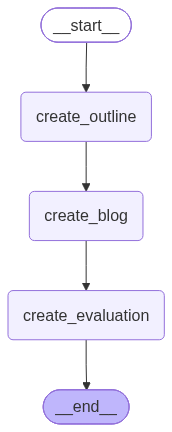

In [67]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())